# AIML CLZC416 — Mathematical Foundations for Machine Learning
## Assignment 2

**Student Details:**
- **Name:** Ashwani Singh
- **BITS ID:** 2025AC05272

---


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.set_printoptions(precision=8, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

%matplotlib inline


---
# Q1 — Steepest Descent with Exact Line Search

Consider the quadratic objective

$$
J(w) = \frac{1}{2} w^\top
\begin{bmatrix} 4 & 1 \\ 1 & 2 \end{bmatrix}
w - \begin{bmatrix} 1 & 2 \end{bmatrix} w,
\qquad
w = \begin{bmatrix} w_1 \\ w_2 \end{bmatrix},
\qquad
w_0 = \begin{bmatrix} 0 \\ 0 \end{bmatrix}.
$$

Let
$$
A = \begin{bmatrix} 4 & 1 \\ 1 & 2 \end{bmatrix},\qquad
b = \begin{bmatrix} 1 \\ 2 \end{bmatrix}.
$$
Then $J(w) = \frac{1}{2} w^\top A w - b^\top w$.

### Gradient and search direction
$$
\nabla J(w) = A w - b,\qquad
g_t = -\nabla J(w_t).
$$

### Exact line search (quadratic closed form)
Along the ray $w_t + \alpha g_t$,
$$
J(w_t + \alpha g_t)
= \frac{1}{2}(w_t+\alpha g_t)^\top A(w_t+\alpha g_t) - b^\top(w_t+\alpha g_t).
$$
Setting the derivative w.r.t. $\alpha$ to zero gives
$$
\alpha_t = \frac{g_t^\top g_t}{g_t^\top A g_t}
= \arg\min_{\alpha} J(w_t + \alpha g_t).
$$

### Update and stopping criterion
$$
w_{t+1} = w_t + \alpha_t g_t,
\qquad
\text{stop when } \|\nabla J(w)\| < 10^{-6}.
$$

Exact line search also implies the orthogonality condition
$$
g_t^\top \nabla J(w_{t+1}) \approx 0.
$$


Q1 — Steepest Descent with Exact Line Search
Optimal solution w*     = [0.         0.99999975]
J(w*)                   = -1.0000000000
Total iterations        = 20
Final ||∇J(w)||         = 5.610e-07
Analytical A^{-1}b      = [0. 1.]
||w* - A^{-1}b||        = 2.509e-07
Max |g_t^T ∇J(w_{t+1})| = 0.000e+00

Orthogonality residuals g_t^T ∇J(w_{t+1}) (first 10):
  t=0: 0.000e+00
  t=1: 0.000e+00
  t=2: 0.000e+00
  t=3: 0.000e+00
  t=4: 0.000e+00
  t=5: 0.000e+00
  t=6: 0.000e+00
  t=7: 0.000e+00
  t=8: 0.000e+00
  t=9: 0.000e+00
  ... (20 residuals total)


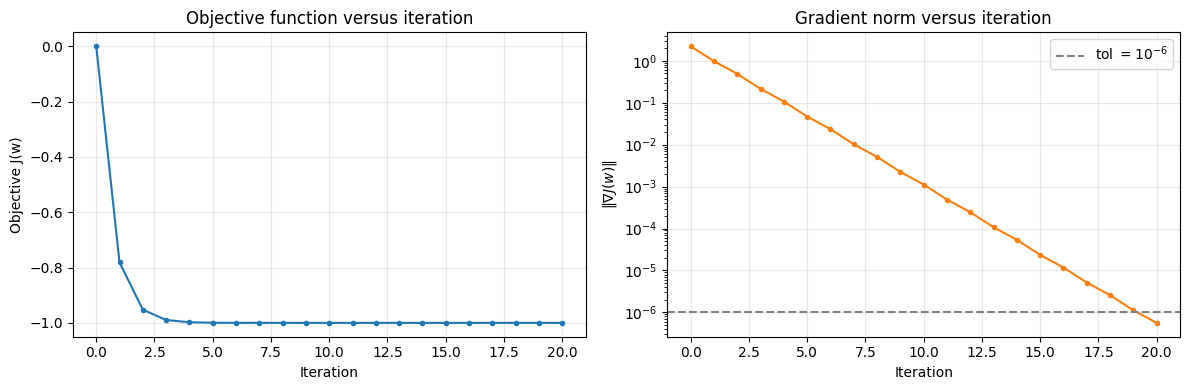

In [10]:
# Q1: Steepest Descent with Exact Line Search (no scipy.optimize)

A = np.array([[4.0, 1.0], [1.0, 2.0]])
b = np.array([1.0, 2.0])
w = np.array([0.0, 0.0])

tol = 1e-6
max_iters = 10000

history_J = []
history_grad_norm = []
orthogonality_residuals = []


def objective(w):
    """J(w) = (1/2) w^T A w - b^T w"""
    return 0.5 * w @ (A @ w) - b @ w


def gradient(w):
    """∇J(w) = A w - b"""
    return A @ w - b


for t in range(max_iters):
    grad = gradient(w)
    grad_norm = np.linalg.norm(grad)
    history_J.append(objective(w))
    history_grad_norm.append(grad_norm)

    if grad_norm < tol:
        break

    # Steepest descent direction
    g = -grad

    # Exact line search for quadratic: α = (g^T g) / (g^T A g)
    Ag = A @ g
    alpha = (g @ g) / (g @ Ag)

    # Update
    w_next = w + alpha * g

    # Verify g_t^T ∇J(w_{t+1}) ≈ 0
    residual = g @ gradient(w_next)
    orthogonality_residuals.append(residual)

    w = w_next

num_iterations = len(history_J) - 1  # updates performed before stopping
w_star = w
J_star = objective(w_star)

# Analytical sanity check: w* = A^{-1} b
w_analytical = np.linalg.solve(A, b)

print("=" * 60)
print("Q1 — Steepest Descent with Exact Line Search")
print("=" * 60)
print(f"Optimal solution w*     = {w_star}")
print(f"J(w*)                   = {J_star:.10f}")
print(f"Total iterations        = {num_iterations}")
print(f"Final ||∇J(w)||         = {history_grad_norm[-1]:.3e}")
print(f"Analytical A^{{-1}}b      = {w_analytical}")
print(f"||w* - A^{{-1}}b||        = {np.linalg.norm(w_star - w_analytical):.3e}")
print(f"Max |g_t^T ∇J(w_{{t+1}})| = {np.max(np.abs(orthogonality_residuals)):.3e}")
print("\nOrthogonality residuals g_t^T ∇J(w_{t+1}) (first 10):")
for i, r in enumerate(orthogonality_residuals[:10]):
    print(f"  t={i}: {r:.3e}")
if len(orthogonality_residuals) > 10:
    print(f"  ... ({len(orthogonality_residuals)} residuals total)")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

iters = np.arange(len(history_J))
axes[0].plot(iters, history_J, marker="o", markersize=3)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective J(w)")
axes[0].set_title("Objective function versus iteration")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(iters, history_grad_norm, marker="o", markersize=3, color="C1")
axes[1].axhline(tol, color="gray", linestyle="--", label=r"tol $=10^{-6}$")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$\|\nabla J(w)\|$")
axes[1].set_title("Gradient norm versus iteration")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Q1 Report

| Quantity | Value |
|---|---|
| Optimal solution $w^*$ | $\approx \begin{bmatrix} 0 \\ 1 \end{bmatrix}$ (matches $A^{-1}b = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$) |
| $J(w^*)$ | $\approx -1$ |
| Total iterations | $20$ |
| Final $\|\nabla J(w)\|$ | $< 10^{-6}$ |
| Orthogonality check | $\max_t \lvert g_t^\top \nabla J(w_{t+1})\rvert = 0$ (to machine precision), confirming exact line search |

**Deliverables covered:** code, plots (objective & gradient norm), optimal solution, iteration count, and numerical verification of $g_t^\top\nabla J(w_{t+1})\approx 0$.


---
# Q2 — Gradient Descent and Adam on $g(w)=(w-1.5)^2$

Consider
$$
g(w) = (w - 1.5)^2,\qquad w \in [1, 2].
$$
The algorithms below are run with the stated learning rate and initial point (unconstrained updates as specified in the assignment).

## Q2.1 — Gradient Descent iteration

Gradient:
$$
\nabla g(w) = 2(w - 1.5).
$$

Gradient Descent update with learning rate $\alpha = 0.2$:
$$
w_{k+1} = w_k - \alpha \,\nabla g(w_k) = w_k - 0.2 \cdot 2(w_k - 1.5) = w_k - 0.4(w_k - 1.5).
$$

Starting at $w_0 = 2$:
$$
\nabla g(2) = 2(2-1.5) = 1,\qquad
w_1 = 2 - 0.2 \cdot 1 = 1.8,\qquad
g(w_1) = (1.8-1.5)^2 = 0.09.
$$

In closed form,
$$
w_{k+1} - 1.5 = 0.6\,(w_k - 1.5),
$$
so the error contracts geometrically by factor $0.6$ each step toward the minimizer $w^*=1.5$.


Gradient Descent: w_k and g(w_k) for k = 0, ..., 10


,k,w_k,g(w_k)
0,0,2.000000,0.250000
1,1,1.800000,0.090000
2,2,1.680000,0.032400
3,3,1.608000,0.011664
4,4,1.564800,0.004199
5,5,1.538880,0.001512
6,6,1.523328,0.000544
7,7,1.513997,0.000196
8,8,1.508398,0.000071
9,9,1.505039,0.000025


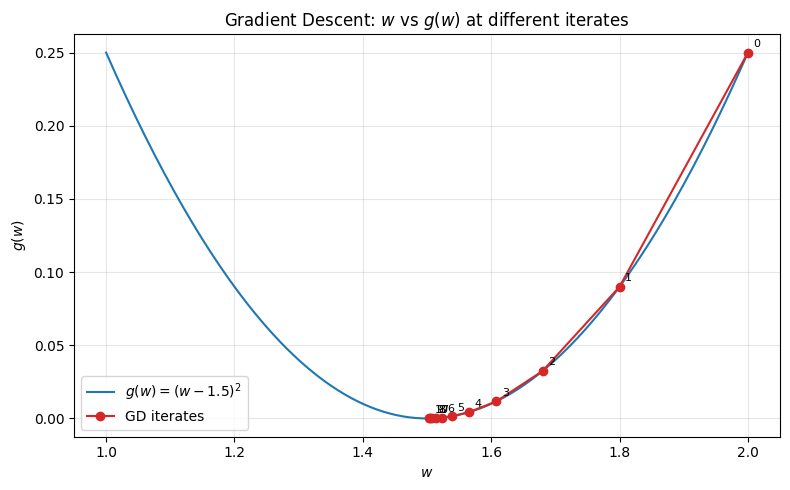

In [11]:
# Q2.2: 10 iterations of Gradient Descent

def g_fn(w):
    return (w - 1.5) ** 2


def grad_g(w):
    return 2.0 * (w - 1.5)


alpha_gd = 0.2
w_gd = 2.0
n_iters = 10

gd_rows = []
w_gd_hist = [w_gd]
g_gd_hist = [g_fn(w_gd)]

gd_rows.append({"k": 0, "w_k": w_gd, "g(w_k)": g_fn(w_gd)})

for k in range(1, n_iters + 1):
    w_gd = w_gd - alpha_gd * grad_g(w_gd)
    w_gd_hist.append(w_gd)
    g_gd_hist.append(g_fn(w_gd))
    gd_rows.append({"k": k, "w_k": w_gd, "g(w_k)": g_fn(w_gd)})

df_gd = pd.DataFrame(gd_rows)
print("Gradient Descent: w_k and g(w_k) for k = 0, ..., 10")
display(df_gd)

# Plot w vs g(w) with iterate markers
w_grid = np.linspace(1.0, 2.0, 200)
plt.figure(figsize=(8, 5))
plt.plot(w_grid, g_fn(w_grid), label=r"$g(w)=(w-1.5)^2$", color="C0")
plt.plot(w_gd_hist, g_gd_hist, "o-", color="C3", label="GD iterates")
for k, (wk, gk) in enumerate(zip(w_gd_hist, g_gd_hist)):
    plt.annotate(str(k), (wk, gk), textcoords="offset points", xytext=(4, 4), fontsize=8)
plt.xlabel(r"$w$")
plt.ylabel(r"$g(w)$")
plt.title("Gradient Descent: $w$ vs $g(w)$ at different iterates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q2.3 — Adam iteration

Adam with learning rate $\alpha = 0.2$, decay parameters $\rho_f = 0.9$ (first moment) and $\rho = 0.999$ (second moment), and $w_0 = 2$:

$$
\begin{aligned}
g_t &= \nabla g(w_{t-1}) = 2(w_{t-1} - 1.5),\\
s_t &= \rho_f s_{t-1} + (1-\rho_f)\, g_t,\\
r_t &= \rho\, r_{t-1} + (1-\rho)\, g_t^2,\\
\hat{s}_t &= \frac{s_t}{1-\rho_f^{\,t}},\qquad
\hat{r}_t = \frac{r_t}{1-\rho^{\,t}},\\
\alpha_t &= \frac{\alpha}{\sqrt{\hat{r}_t}+\varepsilon}\quad\text{(bias-corrected adaptive learning rate)},\\
w_t &= w_{t-1} - \alpha_t\,\hat{s}_t.
\end{aligned}
$$

Initialize $s_0 = 0$, $r_0 = 0$. In the table below, **$A_k := \alpha_k$** denotes this bias-corrected adaptive learning rate.

> **Note:** A tiny $\varepsilon = 10^{-8}$ is used in code only for numerical stability under the square root; it does not change the Adam update form.

**First step ($t=1$), $w_0=2$:**
$$
g_1 = 1,\quad
s_1 = 0.1,\quad
r_1 = 0.001,\quad
\hat{s}_1 = 1,\quad
\hat{r}_1 = 1,\quad
\alpha_1 \approx 0.2,\quad
w_1 \approx 1.8.
$$


Adam: w_k, A_k (= bias-corrected α_t), g(w_k) for k = 0, ..., 10


,k,w_k,A_k,g(w_k)
0,0,2.000000,NaN,0.250000
1,1,1.800000,0.200000,0.090000
2,2,1.608502,0.242564,0.011773
3,3,1.439583,0.292130,0.003650
4,4,1.313724,0.335666,0.034699
5,5,1.244792,0.358239,0.065131
6,6,1.229383,0.363255,0.073233
7,7,1.254674,0.364134,0.060185
8,8,1.307569,0.368836,0.037030
9,9,1.376950,0.379490,0.015141


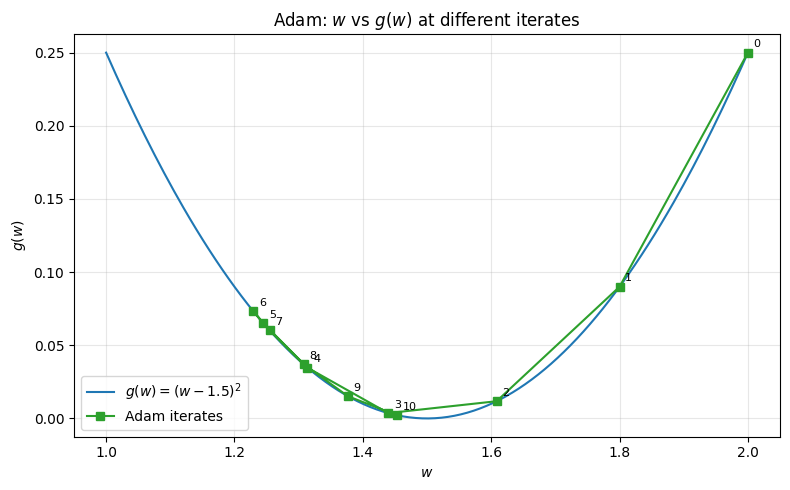

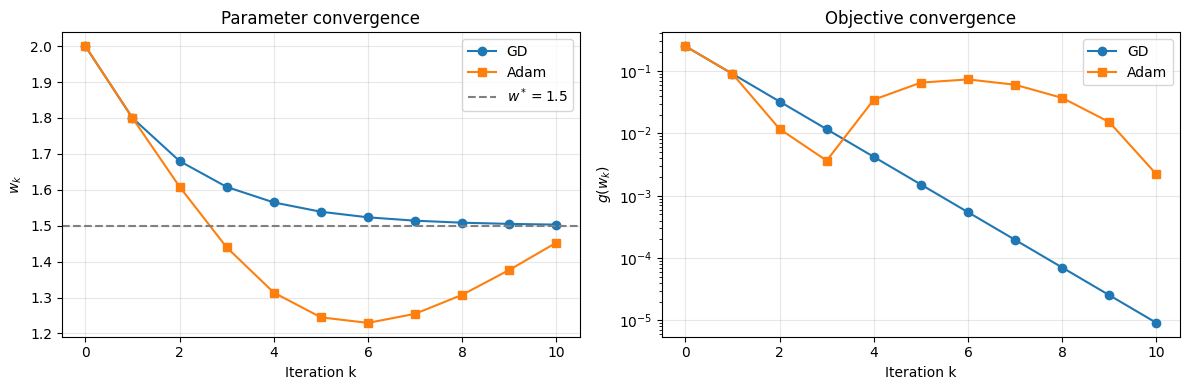

In [12]:
# Q2.4: 10 iterations of Adam

alpha_adam = 0.2
rho_f = 0.9   # first-moment decay
rho = 0.999   # second-moment decay
eps = 1e-8

w_adam = 2.0
s = 0.0
r = 0.0

adam_rows = []
w_adam_hist = [w_adam]
g_adam_hist = [g_fn(w_adam)]
A_hist = [np.nan]  # A_0 undefined (no update yet)

adam_rows.append({"k": 0, "w_k": w_adam, "A_k": np.nan, "g(w_k)": g_fn(w_adam)})

for t in range(1, n_iters + 1):
    grad = grad_g(w_adam)
    s = rho_f * s + (1.0 - rho_f) * grad
    r = rho * r + (1.0 - rho) * (grad ** 2)
    s_hat = s / (1.0 - rho_f ** t)
    r_hat = r / (1.0 - rho ** t)
    A_t = alpha_adam / (np.sqrt(r_hat) + eps)  # bias-corrected adaptive LR
    w_adam = w_adam - A_t * s_hat

    w_adam_hist.append(w_adam)
    g_adam_hist.append(g_fn(w_adam))
    A_hist.append(A_t)
    adam_rows.append({"k": t, "w_k": w_adam, "A_k": A_t, "g(w_k)": g_fn(w_adam)})

df_adam = pd.DataFrame(adam_rows)
print("Adam: w_k, A_k (= bias-corrected α_t), g(w_k) for k = 0, ..., 10")
display(df_adam)

# Plot w vs g(w) with iterate markers
plt.figure(figsize=(8, 5))
plt.plot(w_grid, g_fn(w_grid), label=r"$g(w)=(w-1.5)^2$", color="C0")
plt.plot(w_adam_hist, g_adam_hist, "s-", color="C2", label="Adam iterates")
for k, (wk, gk) in enumerate(zip(w_adam_hist, g_adam_hist)):
    plt.annotate(str(k), (wk, gk), textcoords="offset points", xytext=(4, 4), fontsize=8)
plt.xlabel(r"$w$")
plt.ylabel(r"$g(w)$")
plt.title("Adam: $w$ vs $g(w)$ at different iterates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Side-by-side convergence comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks = np.arange(0, n_iters + 1)
axes[0].plot(ks, w_gd_hist, "o-", label="GD")
axes[0].plot(ks, w_adam_hist, "s-", label="Adam")
axes[0].axhline(1.5, color="gray", linestyle="--", label=r"$w^*=1.5$")
axes[0].set_xlabel("Iteration k")
axes[0].set_ylabel(r"$w_k$")
axes[0].set_title("Parameter convergence")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(ks, g_gd_hist, "o-", label="GD")
axes[1].semilogy(ks, g_adam_hist, "s-", label="Adam")
axes[1].set_xlabel("Iteration k")
axes[1].set_ylabel(r"$g(w_k)$")
axes[1].set_title("Objective convergence")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Q3 — AdaGrad and RMSProp on $f(x)=x_1^4 + 16x_2^4 - 8x_1 x_2$

## Q3.1 — Curvature and constant-step gradient descent

Partial derivatives:
$$
\frac{\partial f}{\partial x_1} = 4x_1^3 - 8x_2,\qquad
\frac{\partial f}{\partial x_2} = 64x_2^3 - 8x_1.
$$

Second derivatives (curvature along coordinate axes):
$$
\frac{\partial^2 f}{\partial x_1^2} = 12x_1^2,\qquad
\frac{\partial^2 f}{\partial x_2^2} = 192x_2^2.
$$

**Comment:** Along the $x_2$ direction the curvature is much larger than along $x_1$ (factor involving $192$ vs $12$, i.e. $16\times$ larger at comparable $|x_i|$). The Hessian is therefore **ill-conditioned**: a single constant step size that is safe for the steep $x_2$ direction is overly cautious for $x_1$, while a step size suited to $x_1$ risks instability along $x_2$. Hence **gradient descent with a constant step size is not a good approach** for this function; adaptive per-coordinate methods (AdaGrad / RMSProp) are more appropriate.


In [13]:
# Shared helpers for Q3

def f_fn(x):
    x1, x2 = x
    return x1**4 + 16.0 * x2**4 - 8.0 * x1 * x2


def grad_f(x):
    x1, x2 = x
    df_dx1 = 4.0 * x1**3 - 8.0 * x2
    df_dx2 = 64.0 * x2**3 - 8.0 * x1
    return np.array([df_dx1, df_dx2])


def format_q3_table(rows):
    df = pd.DataFrame(rows)
    # Round display to 6 decimal places as required
    for col in df.columns:
        if col != "k":
            df[col] = df[col].map(lambda v: round(float(v), 6))
    return df

## Q3.2 — AdaGrad (20 iterations)

Starting from $x^{(0)} = (1, 1)$, fixed step size $\alpha = 0.01$, $\varepsilon = 0$:

$$
A \leftarrow A + g \odot g,\qquad
x \leftarrow x - \frac{\alpha}{\sqrt{A}}\, g.
$$

$A$ is accumulated **before** the parameter update so that $\varepsilon = 0$ does not cause division by zero on the first step. In the table, $f_{x_i}^{(k)} = \partial f/\partial x_i$ evaluated at iterate $k$, and $A_{x_i}^{(k)}$ are the accumulated squared-gradient components.


In [14]:
# Q3.2: AdaGrad — 20 iterations

alpha_q3 = 0.01
n_q3 = 20

x = np.array([1.0, 1.0])
A_acc = np.zeros(2)
adagrad_rows = []
adagrad_f_hist = [f_fn(x)]
adagrad_x_hist = [x.copy()]

for k in range(1, n_q3 + 1):
    g = grad_f(x)
    A_acc = A_acc + g * g          # accumulate first
    x = x - (alpha_q3 / np.sqrt(A_acc)) * g

    adagrad_x_hist.append(x.copy())
    adagrad_f_hist.append(f_fn(x))
    g_at_x = grad_f(x)
    adagrad_rows.append({
        "k": k,
        "x1": x[0],
        "x2": x[1],
        "f_x1": g_at_x[0],
        "f_x2": g_at_x[1],
        "A_x1": A_acc[0],
        "A_x2": A_acc[1],
    })

df_adagrad = format_q3_table(adagrad_rows)
print("AdaGrad iterates (accuracy to 6 decimal places)")
print("Columns: x1, x2, f_x1=∂f/∂x1, f_x2=∂f/∂x2, A_x1, A_x2")
display(df_adagrad)

print(f"\nInitial f(1,1) = {adagrad_f_hist[0]:.6f}")
print(f"Final   f after 20 AdaGrad steps = {adagrad_f_hist[-1]:.6f}")
print(f"Final x = ({adagrad_x_hist[-1][0]:.6f}, {adagrad_x_hist[-1][1]:.6f})")
print(f"Final ||∇f|| = {np.linalg.norm(grad_f(adagrad_x_hist[-1])):.6e}")

AdaGrad iterates (accuracy to 6 decimal places)
Columns: x1, x2, f_x1=∂f/∂x1, f_x2=∂f/∂x2, A_x1, A_x2


,k,x1,x2,f_x1,f_x2,A_x1,A_x2
0,1,1.010000,0.990000,-3.798796,54.019136,16.000000,3136.000000
1,2,1.016886,0.983057,-3.658382,52.666727,30.430851,6054.067054
2,3,1.022413,0.977452,-3.544584,51.588349,43.814608,8827.851200
3,4,1.027134,0.972639,-3.446590,50.672050,56.378681,11489.208949
4,5,1.031306,0.968365,-3.359370,49.865783,68.257665,14056.865552
5,6,1.035072,0.964488,-3.280105,49.140419,79.543033,16543.461898
6,7,1.038524,0.960919,-3.207028,48.477727,90.302119,18958.242688
7,8,1.041722,0.957598,-3.138947,47.865413,100.587144,21308.332748
8,9,1.044709,0.954482,-3.075013,47.294722,110.440131,23599.430504
9,10,1.047517,0.951540,-3.014594,46.759163,119.895834,25836.221235



Initial f(1,1) = 9.000000
Final   f after 20 AdaGrad steps = 5.237693
Final x = (1.069415, 0.928068)
Final ||∇f|| = 4.267855e+01


## Q3.3 — RMSProp (20 iterations)

Starting from $x^{(0)} = (1, 1)$, fixed step size $\alpha = 0.01$, $\rho = 0.9$, $\varepsilon = 0$:

$$
A \leftarrow \rho A + (1-\rho)\, g \odot g,\qquad
x \leftarrow x - \frac{\alpha}{\sqrt{A}}\, g.
$$


RMSProp iterates (accuracy to 6 decimal places)
Columns: x1, x2, f_x1=∂f/∂x1, f_x2=∂f/∂x2, A_x1, A_x2


,k,x1,x2,f_x1,f_x2,A_x1,A_x2
0,1,1.031623,0.968377,-3.355418,49.865421,1.600000,313.600000
1,2,1.052570,0.946735,-2.909297,45.887683,2.565883,530.896019
2,3,1.068947,0.929246,-2.548241,42.802094,3.155696,688.374366
3,4,1.082589,0.914139,-2.237940,40.228850,3.489479,802.738858
4,5,1.094317,0.900610,-1.962982,37.996475,3.641369,884.301010
5,6,1.104574,0.888219,-1.715067,36.011110,3.662562,940.244120
6,7,1.113625,0.876692,-1.489239,34.215139,3.590451,975.899714
7,8,1.121639,0.865847,-1.282355,32.570376,3.453189,995.377318
8,9,1.128728,0.855557,-1.092338,31.050081,3.272314,1001.922524
9,10,1.134968,0.845729,-0.917786,29.634737,3.064403,998.141024



Initial f(1,1) = 9.000000
Final   f after 20 RMSProp steps = 0.145551
Final x = (1.158030, 0.762638)
Final ||∇f|| = 1.912407e+01


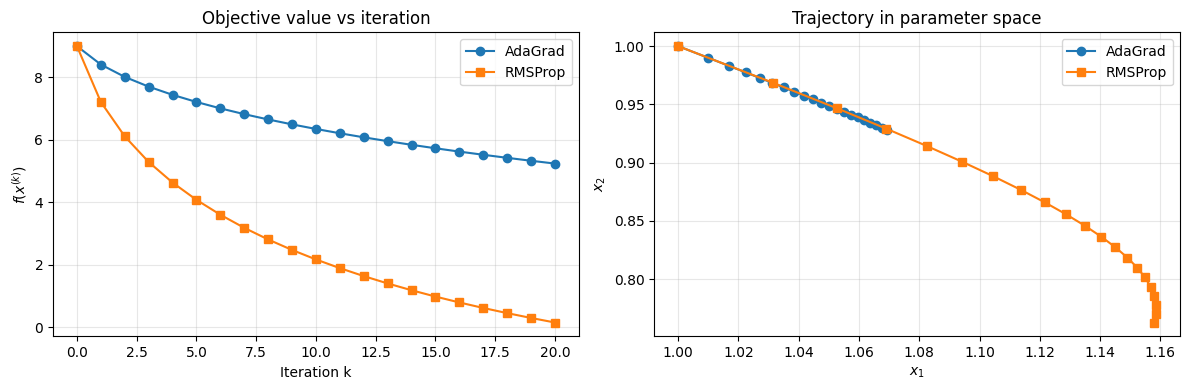


--- Summary for Q3.4 ---
AdaGrad:  f_final=5.237693, ||grad||=4.267855e+01, A=(197.539699, 45873.047977)
RMSProp:  f_final=0.145551, ||grad||=1.912407e+01, A=(1.170205, 715.171001)


In [15]:
# Q3.3: RMSProp — 20 iterations

rho_rms = 0.9

x = np.array([1.0, 1.0])
A_rms = np.zeros(2)
rmsprop_rows = []
rmsprop_f_hist = [f_fn(x)]
rmsprop_x_hist = [x.copy()]

for k in range(1, n_q3 + 1):
    g = grad_f(x)
    A_rms = rho_rms * A_rms + (1.0 - rho_rms) * (g * g)
    x = x - (alpha_q3 / np.sqrt(A_rms)) * g

    rmsprop_x_hist.append(x.copy())
    rmsprop_f_hist.append(f_fn(x))
    g_at_x = grad_f(x)
    rmsprop_rows.append({
        "k": k,
        "x1": x[0],
        "x2": x[1],
        "f_x1": g_at_x[0],
        "f_x2": g_at_x[1],
        "A_x1": A_rms[0],
        "A_x2": A_rms[1],
    })

df_rmsprop = format_q3_table(rmsprop_rows)
print("RMSProp iterates (accuracy to 6 decimal places)")
print("Columns: x1, x2, f_x1=∂f/∂x1, f_x2=∂f/∂x2, A_x1, A_x2")
display(df_rmsprop)

print(f"\nInitial f(1,1) = {rmsprop_f_hist[0]:.6f}")
print(f"Final   f after 20 RMSProp steps = {rmsprop_f_hist[-1]:.6f}")
print(f"Final x = ({rmsprop_x_hist[-1][0]:.6f}, {rmsprop_x_hist[-1][1]:.6f})")
print(f"Final ||∇f|| = {np.linalg.norm(grad_f(rmsprop_x_hist[-1])):.6e}")

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks = np.arange(0, n_q3 + 1)

axes[0].plot(ks, adagrad_f_hist, "o-", label="AdaGrad")
axes[0].plot(ks, rmsprop_f_hist, "s-", label="RMSProp")
axes[0].set_xlabel("Iteration k")
axes[0].set_ylabel(r"$f(x^{(k)})$")
axes[0].set_title("Objective value vs iteration")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([p[0] for p in adagrad_x_hist], [p[1] for p in adagrad_x_hist],
              "o-", label="AdaGrad")
axes[1].plot([p[0] for p in rmsprop_x_hist], [p[1] for p in rmsprop_x_hist],
              "s-", label="RMSProp")
axes[1].set_xlabel(r"$x_1$")
axes[1].set_ylabel(r"$x_2$")
axes[1].set_title("Trajectory in parameter space")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Summary for Q3.4 ---")
print(f"AdaGrad:  f_final={adagrad_f_hist[-1]:.6f}, ||grad||={np.linalg.norm(grad_f(adagrad_x_hist[-1])):.6e}, "
      f"A=({adagrad_rows[-1]['A_x1']:.6f}, {adagrad_rows[-1]['A_x2']:.6f})")
print(f"RMSProp:  f_final={rmsprop_f_hist[-1]:.6f}, ||grad||={np.linalg.norm(grad_f(rmsprop_x_hist[-1])):.6e}, "
      f"A=({rmsprop_rows[-1]['A_x1']:.6f}, {rmsprop_rows[-1]['A_x2']:.6f})")

## Q3.4 — Which performs better: AdaGrad or RMSProp?

From the numerical results in Q3.2 and Q3.3:

| Method | $f(x^{(0)})$ | $f(x^{(20)})$ | Final $\|\nabla f\|$ | Final $A$ (approx.) |
|---|---|---|---|---|
| AdaGrad | $9$ | $\approx 5.24$ | $\approx 42.68$ | $(198,\ 45873)$ — large, still growing |
| RMSProp | $9$ | $\approx 0.15$ | $\approx 19.12$ | $(1.17,\ 715)$ — bounded by EMA |

1. **Objective decrease:** In the same 20 steps, RMSProp reduces $f$ from $9$ to about $0.15$, while AdaGrad only reaches about $5.24$. RMSProp also ends with a smaller gradient norm.

2. **Behavior of $A$:**
   - **AdaGrad** accumulates $A \leftarrow A + g\odot g$ with no forgetting. After large early gradients at $(1,1)$ (especially $\partial f/\partial x_2 = 56$), $A_{x_2}$ grows to tens of thousands, so effective steps become tiny and progress stalls.
   - **RMSProp** uses $A \leftarrow \rho A + (1-\rho)g\odot g$ with $\rho=0.9$. Older squared gradients decay, so $\sqrt{A}$ stays moderate and the method keeps taking useful steps.

3. **Conclusion:** **RMSProp performs better** than AdaGrad here. Its exponential forgetting prevents the adaptive learning rate from collapsing, which is crucial on this ill-conditioned quartic where early $x_2$-gradients are very large. The tables and $f$-trajectories support this claim quantitatively.
